Load libraries for data, math, and plots.

In [ ]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

Read the dataset.

In [ ]:
medical_df = pd.read_csv('medical.csv')

Filter to non-smokers for a cleaner baseline.

In [ ]:
non_smoker_df = medical_df[medical_df['smoker'] == 'no']

Plot age vs charges for a quick look.

<Axes: title={'center': 'Scatter Plot of Age vs. Charges'}, xlabel='age', ylabel='charges'>

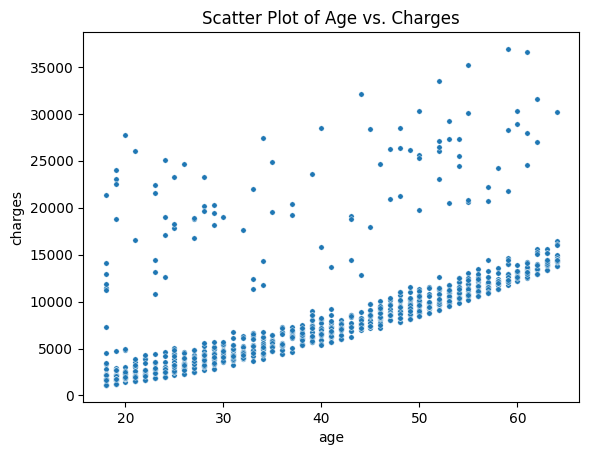

In [ ]:
plt.title('Scatter Plot of Age vs. Charges')
sns.scatterplot(x='age', y='charges', data=non_smoker_df ,s=15)

### Model
    y = wx + b
    charges = w*age + b
    

Define the linear model formula.

In [ ]:
def estimate_charges(age, w, b):
    return w * age + b

In [ ]:
w = 300
b = -4500

### Cost Function

Define RMSE to measure error.

In [ ]:
def rmse(w, b, non_smoker_df):
    ages = non_smoker_df['age']
    estimated_charges = estimate_charges(ages, w, b)
    predicted_charges = non_smoker_df['charges']
    squared_errors = (estimated_charges - predicted_charges) ** 2
    mse = squared_errors.mean()
    return np.sqrt(mse)

Try different parameters and visualize fit.

In [ ]:
def try_parameters(w, b):
    ages = non_smoker_df['age']
    estimated_charges = estimate_charges(ages, w, b)

    plt.figure(figsize=(10, 6))
    plt.title('Scatter Plot of Age vs. Actual Charges with Estimated Charges Line')
    sns.scatterplot(x='age', y='charges', data=non_smoker_df ,s=15, label='Actual Charges')
    sns.lineplot(x='age', y=estimated_charges, data=non_smoker_df, color='red', label='Estimated Charges')

    print("Root mean squared error:", rmse(w, b, non_smoker_df))

Root mean squared error: 6826.734303208685


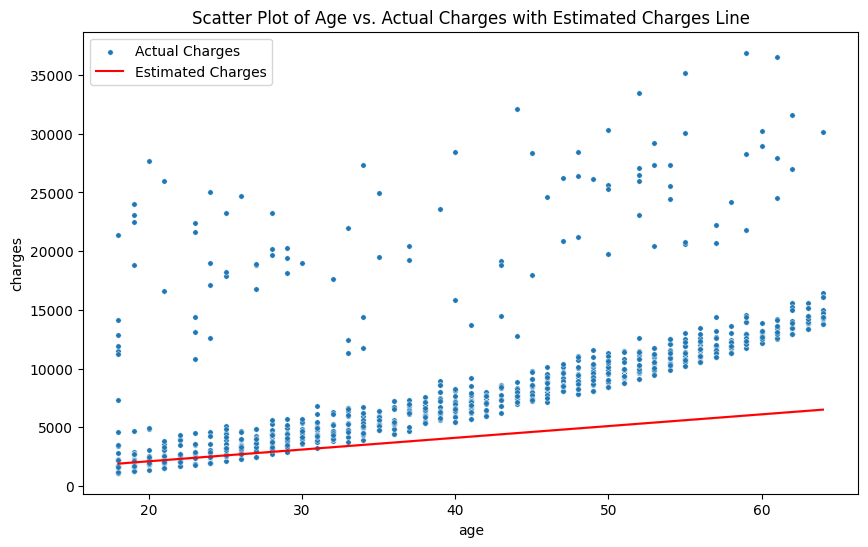

In [ ]:
try_parameters(100,100)

Root mean squared error: 12707.75158825895


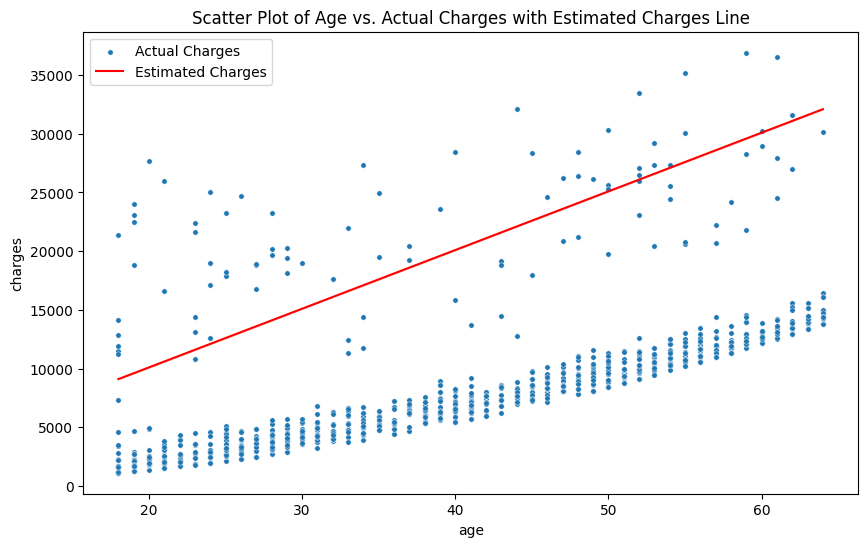

In [ ]:
try_parameters(500, 100)

Root mean squared error: 4956.973980899423


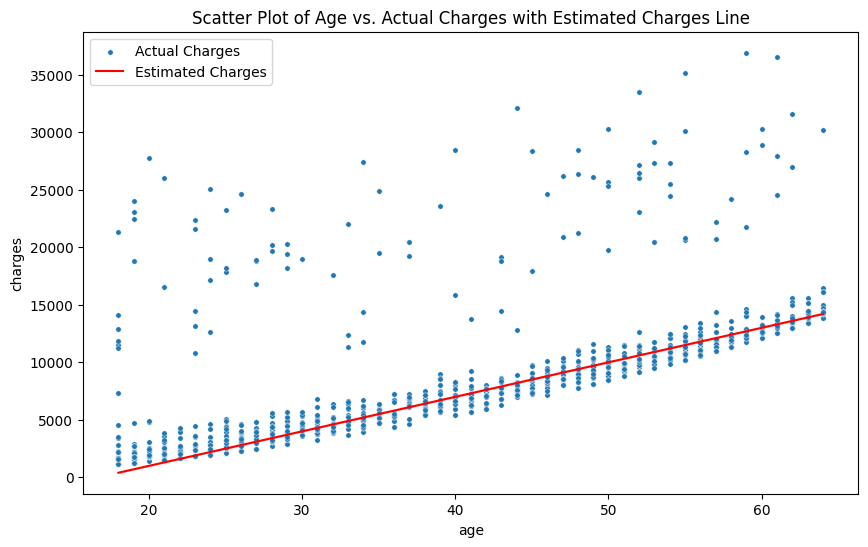

In [ ]:
try_parameters(300, -5000)

Root mean squared error: 4686.746277005344


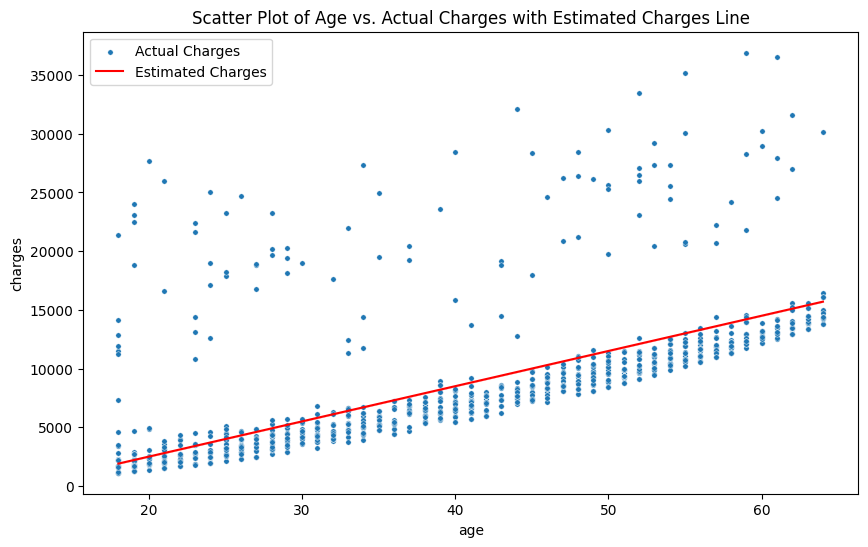

In [ ]:
try_parameters(300, -3500)

In [ ]:
non_smoker_df = medical_df[medical_df['smoker'] == 'no']

In [ ]:
ages = non_smoker_df['age']
estimated_charges = estimate_charges(ages, w, b)
predicted_charges = non_smoker_df['charges']

### Scikit-learn

Use scikit-learn to fit parameters automatically.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.
    
    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.
    
    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.
    
        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.
    
    Returns
    -------
    self : object
        Fitted Estimator.



Prepare inputs and targets.

In [ ]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df['charges']
print(inputs.shape)
print(targets.shape)

(1064, 1)
(1064,)


Fit the model on the data.

In [ ]:
model.fit(inputs, targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Make a few sample predictions.

In [ ]:
model.predict(pd.DataFrame({'age': [23, 37, 61]}))

array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [ ]:
def rmse():
    ages = non_smoker_df['age']
    estimated_charges = model.predict(non_smoker_df[['age']])
    predicted_charges = non_smoker_df['charges']
    squared_errors = (estimated_charges - predicted_charges) ** 2
    mse = squared_errors.mean()
    return np.sqrt(mse)

Compute error on the dataset.

In [ ]:
print("Coefficient (w):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Coefficient (w): 267.2489128311997
Intercept (b): -2091.4205565650864


In [ ]:
rmse()

np.float64(4662.505766636395)

Plot the fitted line over the data.

<Axes: title={'center': 'Scatter Plot of Age vs. Actual Charges with Estimated Charges Line'}, xlabel='age', ylabel='charges'>

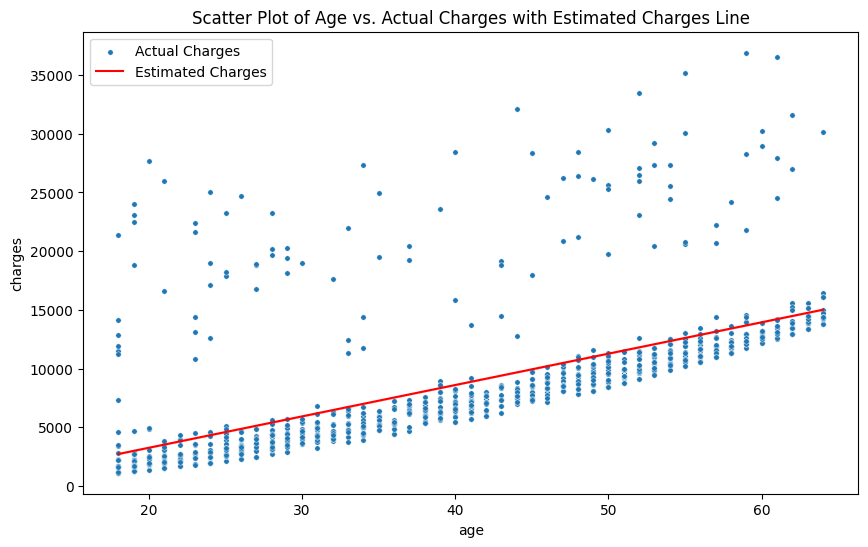

In [ ]:
# model parameters
w = model.coef_[0]
b = model.intercept_

estimated_charges = estimate_charges(ages, w, b)

plt.figure(figsize=(10, 6))
plt.title('Scatter Plot of Age vs. Actual Charges with Estimated Charges Line')
sns.scatterplot(x='age', y='charges', data=non_smoker_df ,s=15, label='Actual Charges')
sns.lineplot(x='age', y=estimated_charges, data=non_smoker_df, color='red', label='Estimated Charges')
